# figure 4 -- piaget

## Perspective Taking metrics summary

Saved combined per-seed and aggregated table to ../results/figure_4_tom_piaget_all/table_piaget.pdf


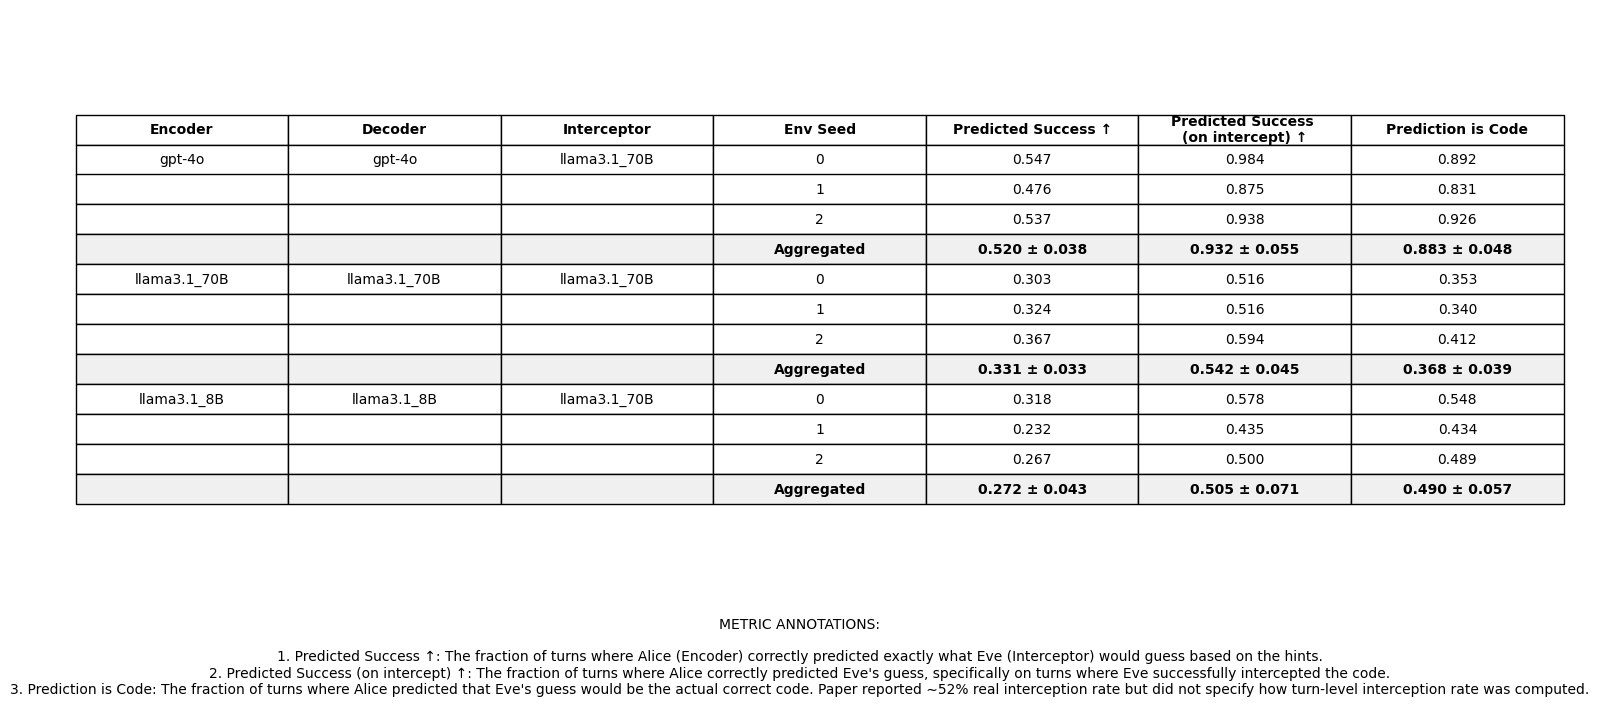

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

def generate_piaget_table_pdf(csv_path, output_pdf):
  # 1. Load the data
  df = pd.read_csv(csv_path)
  
  # 2. Define the columns we care about
  group_cols = ['encoder', 'decoder', 'interceptor']
  metric_cols = [
      'avg_predicted_success', 
      'avg_predicted_success_on_intercept', 
      'avg_prediction_is_code'
  ]
  
  # Sort the dataframe to ensure seeds are ordered nicely
  df = df.sort_values(by=group_cols + ['env_seed'])
  
  # 3. Construct the formatted data
  table_data = []
  
  grouped = df.groupby(group_cols)
  
  for name, group in grouped:
      enc, dec, intc = name
      
      # Add the per-seed rows
      first_row = True
      for _, row in group.iterrows():
          table_data.append({
              # Only show the model names on the first row of the group (emulating a merged cell)
              'Encoder': enc if first_row else "",
              'Decoder': dec if first_row else "",
              'Interceptor': intc if first_row else "",
              'Env Seed': str(int(row['env_seed'])),
              'Predicted Success ↑': f"{row['avg_predicted_success']:.3f}",
              'Predicted Success \n(on intercept) ↑': f"{row['avg_predicted_success_on_intercept']:.3f}",
              'Prediction is Code': f"{row['avg_prediction_is_code']:.3f}"
          })
          first_row = False
          
      # Calculate the aggregation for this specific group
      mean_vals = group[metric_cols].mean()
      std_vals = group[metric_cols].std()
      
      # Append the Aggregated row right below the individual seeds
      table_data.append({
          'Encoder': "",
          'Decoder': "",
          'Interceptor': "",
          'Env Seed': "Aggregated",
          'Predicted Success ↑': f"{mean_vals['avg_predicted_success']:.3f} ± {std_vals['avg_predicted_success']:.3f}",
          'Predicted Success \n(on intercept) ↑': f"{mean_vals['avg_predicted_success_on_intercept']:.3f} ± {std_vals['avg_predicted_success_on_intercept']:.3f}",
          'Prediction is Code': f"{mean_vals['avg_prediction_is_code']:.3f} ± {std_vals['avg_prediction_is_code']:.3f}"
      })
      
  formatted_df = pd.DataFrame(table_data)
  
  # 4. Create a plot to render the table as a PDF
  # Dynamically scale the figure height based on the number of rows
  fig, ax = plt.subplots(figsize=(16, len(formatted_df) * 0.4 + 3))
  ax.axis('tight')
  ax.axis('off')
  
  # Create the table on the matplotlib axis
  table = ax.table(
      cellText=formatted_df.values,
      colLabels=formatted_df.columns,
      cellLoc='center',
      loc='center'
  )
  
  # Style the table
  table.auto_set_font_size(False)
  table.set_fontsize(10)
  table.scale(1.2, 1.8)  # Expand table dimensions slightly
  
  # Make the header row bold and highlight aggregated rows
  for (row, col), cell in table.get_celld().items():
      if row == 0:
          cell.set_text_props(weight='bold')
      elif row > 0:
          # If the "Env Seed" column is "Aggregated", make the entire row bold with a gray background
          if formatted_df.iloc[row - 1]['Env Seed'] == "Aggregated":
              cell.set_text_props(weight='bold')
              cell.set_facecolor('#f0f0f0')  # Light gray background
  
  # 5. Add Metric Annotations below the table
  annotations = (
      "METRIC ANNOTATIONS:\n\n"
      "1. Predicted Success ↑: The fraction of turns where Alice (Encoder) correctly predicted exactly what Eve (Interceptor) would guess based on the hints.\n"
      "2. Predicted Success (on intercept) ↑: The fraction of turns where Alice correctly predicted Eve's guess, specifically on turns where Eve successfully intercepted the code.\n"
      "3. Prediction is Code: The fraction of turns where Alice predicted that Eve's guess would be the actual correct code. Paper reported ∼52% real interception rate but did not specify how turn-level interception rate was computed."
  )
  
  # Place text near the bottom of the figure
  plt.text(0.5, 0.05, annotations, ha='center', va='center', fontsize=10, transform=fig.transFigure, wrap=True)
  
  # 6. Save as PDF
  plt.savefig(output_pdf, format='pdf', bbox_inches='tight')
  print(f"Saved combined per-seed and aggregated table to {output_pdf}")


csv_path = "../results/figure_4_tom_piaget_all/experiment_summary.csv"
output_pdf = "../results/figure_4_tom_piaget_all/table_piaget.pdf"
generate_piaget_table_pdf(csv_path, output_pdf)

## real *turn-based* interception-rate

not episode-based

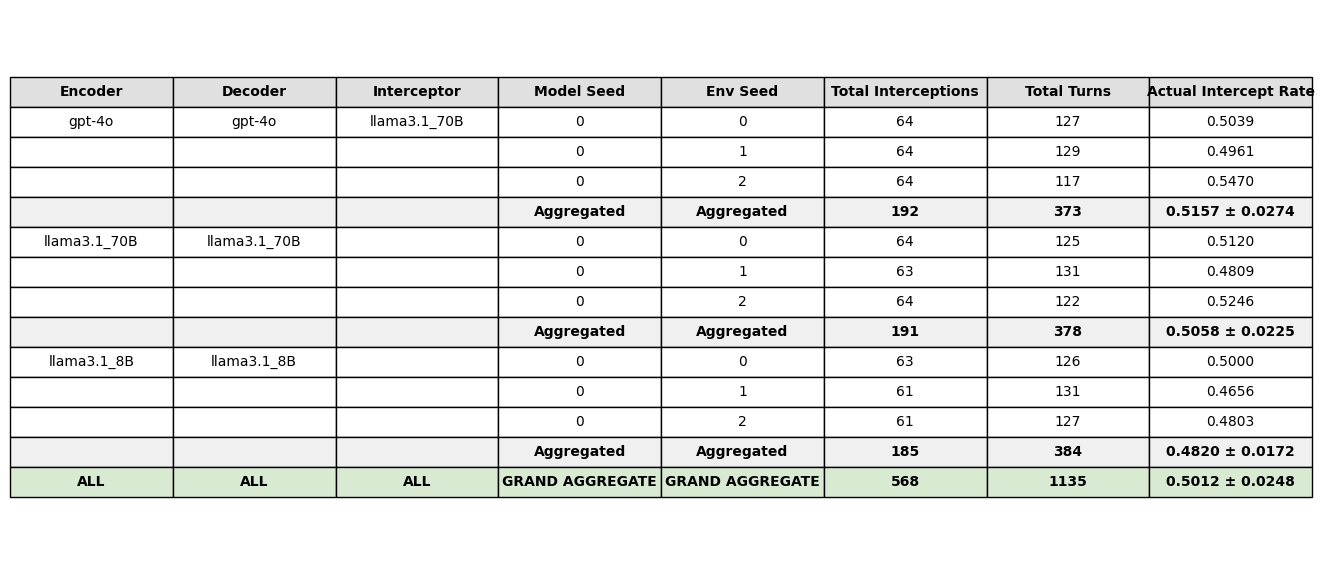

In [11]:
import os
import json
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def compute_exact_turn_based_rates(base_results_dir):
    results = []
    
    # 1. Iterate through all model_seed folders (e.g., model_seed0, model_seed1...)
    for model_seed_dir in sorted(os.listdir(base_results_dir)):
        if not model_seed_dir.startswith("model_seed"):
            continue
            
        model_seed_path = os.path.join(base_results_dir, model_seed_dir)
        if not os.path.isdir(model_seed_path):
            continue
            
        # Parse the model seed integer (e.g. model_seed0 -> 0)
        m_seed = int(model_seed_dir.replace("model_seed", ""))
            
        # 2. Iterate through all model configs
        for model_config in sorted(os.listdir(model_seed_path)):
            model_path = os.path.join(model_seed_path, model_config)
            if not os.path.isdir(model_path):
                continue
                
            parts = re.split("-|_", model_config)
            if "gpt" in model_config:
                if model_config.startswith("gpt-4o_gpt-4o"):
                    encoder = "gpt-4o"
                    decoder = "gpt-4o"
                    interceptor = "llama3.1_70B"
                else:
                    encoder = "unknown"
                    decoder = "unknown"
                    interceptor = "unknown"
            else:
                encoder = "_".join(parts[0:2])
                decoder = "_".join(parts[2:4])
                interceptor = "_".join(parts[4:6])

            # 3. Iterate through env seeds
            for env_seed_dir in sorted(os.listdir(model_path)):
                seed_path = os.path.join(model_path, env_seed_dir)
                if not os.path.isdir(seed_path):
                    continue
                    
                env_seed = int(env_seed_dir.replace("env_seed", ""))
                
                total_interceptions = 0
                total_turns = 0
                
                # 4. Iterate through episodes
                for ep_dir in os.listdir(seed_path):
                    ep_path = os.path.join(seed_path, ep_dir)
                    if not os.path.isdir(ep_path):
                        continue
                        
                    stats_file = os.path.join(ep_path, f"stats_{ep_dir}.json")
                    if os.path.exists(stats_file):
                        with open(stats_file, "r") as f:
                            stats = json.load(f)
                            total_interceptions += len(stats.get("intercept_turns", []))
                            total_turns += stats.get("turns", 0)
                
                rate = total_interceptions / total_turns if total_turns > 0 else np.nan
                
                results.append({
                    "Encoder": encoder,
                    "Decoder": decoder,
                    "Interceptor": interceptor,
                    "Model Seed": str(m_seed),
                    "Env Seed": str(env_seed),
                    "Total Interceptions": total_interceptions,
                    "Total Turns": total_turns,
                    "Actual Intercept Rate": rate
                })

    df_per_seed = pd.DataFrame(results)
    
    # 5. Aggregate per model combination across ALL seeds (model seed + env seed)
    aggregated_rows = []
    group_cols = ["Encoder", "Decoder", "Interceptor"]
    
    for name, group in df_per_seed.groupby(group_cols):
        encoder, decoder, interceptor = name
        
        mean_rate = group["Actual Intercept Rate"].mean()
        std_rate = group["Actual Intercept Rate"].std()
        total_intercepts_agg = group["Total Interceptions"].sum()
        total_turns_agg = group["Total Turns"].sum()
        
        aggregated_rows.append({
            "Encoder": encoder,
            "Decoder": decoder,
            "Interceptor": interceptor,
            "Model Seed": "Aggregated",
            "Env Seed": "Aggregated",
            "Total Interceptions": str(total_intercepts_agg),
            "Total Turns": str(total_turns_agg),
            "Actual Intercept Rate": f"{mean_rate:.4f} ± {std_rate:.4f}"
        })
        
    df_aggregated = pd.DataFrame(aggregated_rows)
    
    # 6. Grand Aggregation across EVERYTHING
    overall_mean = df_per_seed["Actual Intercept Rate"].mean()
    overall_std = df_per_seed["Actual Intercept Rate"].std()
    overall_total_intercepts = df_per_seed["Total Interceptions"].sum()
    overall_total_turns = df_per_seed["Total Turns"].sum()
    
    grand_agg_row = pd.DataFrame([{
        "Encoder": "ALL",
        "Decoder": "ALL",
        "Interceptor": "ALL",
        "Model Seed": "GRAND AGGREGATE",
        "Env Seed": "GRAND AGGREGATE",
        "Total Interceptions": str(overall_total_intercepts),
        "Total Turns": str(overall_total_turns),
        "Actual Intercept Rate": f"{overall_mean:.4f} ± {overall_std:.4f}"
    }])
    
    # 7. Format and Sort
    df_per_seed["Actual Intercept Rate"] = df_per_seed["Actual Intercept Rate"].apply(lambda x: f"{x:.4f}")
    df_per_seed["Total Interceptions"] = df_per_seed["Total Interceptions"].astype(str)
    df_per_seed["Total Turns"] = df_per_seed["Total Turns"].astype(str)
    
    final_df = pd.concat([df_per_seed, df_aggregated]).sort_values(
        by=group_cols + ["Model Seed", "Env Seed"], 
        key=lambda col: col.map(lambda x: "Z_Aggregated" if x == "Aggregated" else x)
    ).reset_index(drop=True)
    
    final_df = pd.concat([final_df, grand_agg_row]).reset_index(drop=True)
    
    for col in group_cols:
        final_df[col] = final_df[col].mask(final_df[col] == final_df[col].shift(1), "")
        
    return final_df

def export_to_pdf(df, output_path):
    fig, ax = plt.subplots(figsize=(14, len(df) * 0.4 + 2))
    ax.axis('tight')
    ax.axis('off')
    
    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc='center',
        loc='center'
    )
    
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.8)
    
    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_text_props(weight='bold')
            cell.set_facecolor('#e0e0e0')
        elif row > 0:
            env_seed_val = df.iloc[row - 1]['Env Seed']
            if env_seed_val == "Aggregated":
                cell.set_text_props(weight='bold')
                cell.set_facecolor('#f0f0f0')
            elif env_seed_val == "GRAND AGGREGATE":
                cell.set_text_props(weight='bold')
                cell.set_facecolor('#d9ead3')
                
    plt.savefig(output_path, format='pdf', bbox_inches='tight')


# Run the function
base_results_dir = "../results/figure_4_tom_piaget_all"
output_pdf = "../results/figure_4_tom_piaget_all/real_turn_intercept_rates.pdf"
df_rates = compute_exact_turn_based_rates(base_results_dir)
export_to_pdf(df_rates, output_pdf)

# figure 4 -- gopnik

Saved to ../results/figure_4_tom_gopnik_all/table_gopnik.pdf


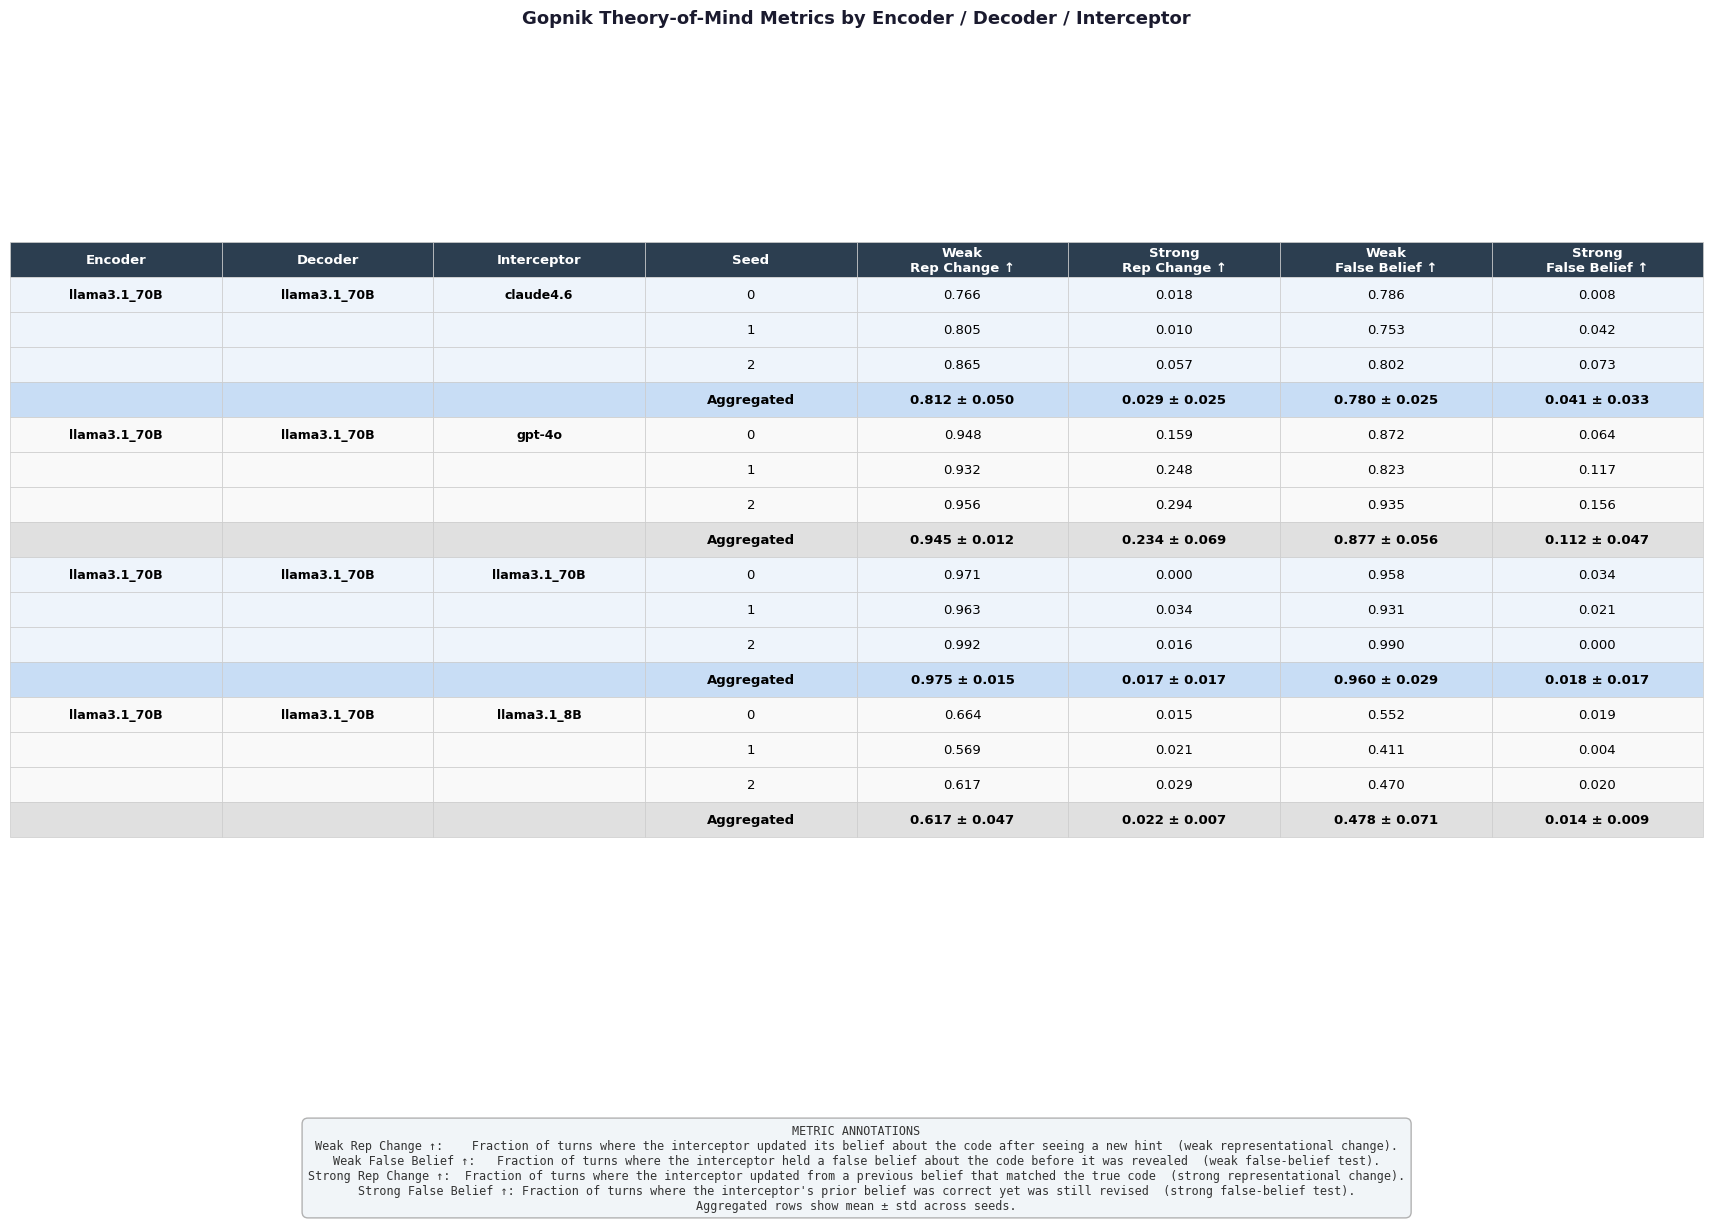

In [2]:
import pandas as pd
import matplotlib.pyplot as plt


def generate_gopnik_table_pdf(csv_path, output_pdf):
    df = pd.read_csv(csv_path)

    group_cols = ['encoder', 'decoder', 'interceptor']
    metric_cols = [
        'gopnik_weak_rep_change',
        'gopnik_strong_rep_change',
        'gopnik_weak_false_belief',
        'gopnik_strong_false_belief',
    ]

    df = df.sort_values(by=group_cols + ['env_seed'])

    table_data = []
    row_is_aggregated = []
    row_group_idx = []

    for g_idx, (name, group) in enumerate(df.groupby(group_cols, sort=False)):
        enc, dec, intc = name
        first_row = True

        for _, row in group.iterrows():
            table_data.append({
                'Encoder': enc if first_row else '',
                'Decoder': dec if first_row else '',
                'Interceptor': intc if first_row else '',
                'Seed': str(int(row['env_seed'])),
                'Weak\nRep Change ↑': f"{row['gopnik_weak_rep_change']:.3f}",
                'Strong\nRep Change ↑': f"{row['gopnik_strong_rep_change']:.3f}",
                'Weak\nFalse Belief ↑': f"{row['gopnik_weak_false_belief']:.3f}",
                'Strong\nFalse Belief ↑': f"{row['gopnik_strong_false_belief']:.3f}",
            })
            row_is_aggregated.append(False)
            row_group_idx.append(g_idx)
            first_row = False

        mean_vals = group[metric_cols].mean()
        std_vals  = group[metric_cols].std()

        table_data.append({
            'Encoder': '',
            'Decoder': '',
            'Interceptor': '',
            'Seed': 'Aggregated',
            'Weak\nRep Change ↑': f"{mean_vals['gopnik_weak_rep_change']:.3f} ± {std_vals['gopnik_weak_rep_change']:.3f}",
            'Strong\nRep Change ↑': f"{mean_vals['gopnik_strong_rep_change']:.3f} ± {std_vals['gopnik_strong_rep_change']:.3f}",
            'Weak\nFalse Belief ↑': f"{mean_vals['gopnik_weak_false_belief']:.3f} ± {std_vals['gopnik_weak_false_belief']:.3f}",
            'Strong\nFalse Belief ↑': f"{mean_vals['gopnik_strong_false_belief']:.3f} ± {std_vals['gopnik_strong_false_belief']:.3f}",
        })
        row_is_aggregated.append(True)
        row_group_idx.append(g_idx)

    formatted_df = pd.DataFrame(table_data)

    n_rows = len(formatted_df)
    fig_height = n_rows * 0.55 + 3.5
    fig, ax = plt.subplots(figsize=(17, fig_height))
    ax.axis('tight')
    ax.axis('off')
    fig.patch.set_facecolor('white')

    table = ax.table(
        cellText=formatted_df.values,
        colLabels=formatted_df.columns,
        cellLoc='center',
        loc='center',
    )

    table.auto_set_font_size(False)
    table.set_fontsize(9.5)
    table.scale(1.15, 2.0)

    # Color palette: alternating group backgrounds
    alt_bg    = ['#EEF4FB', '#F9F9F9']  # per-seed row backgrounds (alternates by group)
    agg_bg    = ['#C8DDF5', '#E0E0E0']  # aggregated row backgrounds (alternates by group)
    header_color = '#2C3E50'

    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor('#CCCCCC')
        cell.set_linewidth(0.5)

        if row == 0:
            cell.set_facecolor(header_color)
            cell.set_text_props(weight='bold', color='white', fontsize=9.5)
        else:
            data_row = row - 1
            g = row_group_idx[data_row]
            is_agg = row_is_aggregated[data_row]

            if is_agg:
                cell.set_facecolor(agg_bg[g % 2])
                cell.set_text_props(weight='bold', fontsize=9.5)
            else:
                cell.set_facecolor(alt_bg[g % 2])

            # Bold the model name in the first occurrence of each group
            if col < 3 and formatted_df.iloc[data_row].iloc[col] != '':
                cell.set_text_props(weight='bold', fontsize=9)

    ax.set_title(
        "Gopnik Theory-of-Mind Metrics by Encoder / Decoder / Interceptor",
        fontsize=13, fontweight='bold', pad=14, color='#1a1a2e'
    )

    annotations = (
        "METRIC ANNOTATIONS\n"
        "Weak Rep Change ↑:    Fraction of turns where the interceptor updated its belief about the code after seeing a new hint  (weak representational change).\n"
        "Weak False Belief ↑:   Fraction of turns where the interceptor held a false belief about the code before it was revealed  (weak false-belief test).\n"
        "Strong Rep Change ↑:  Fraction of turns where the interceptor updated from a previous belief that matched the true code  (strong representational change).\n"
        "Strong False Belief ↑: Fraction of turns where the interceptor's prior belief was correct yet was still revised  (strong false-belief test).\n"
        "Aggregated rows show mean ± std across seeds."
    )

    plt.figtext(
        0.5, 0.01, annotations,
        ha='center', va='bottom',
        fontsize=8.5,
        color='#333333',
        fontfamily='monospace',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#F0F4F8', edgecolor='#AAAAAA', alpha=0.9)
    )

    plt.tight_layout(rect=[0, 0.14, 1, 1])
    plt.savefig(output_pdf, format='pdf', bbox_inches='tight', dpi=150)
    print(f"Saved to {output_pdf}")


csv_path   = "../results/figure_4_tom_gopnik_all/experiment_summary.csv"
output_pdf = "../results/figure_4_tom_gopnik_all/table_gopnik.pdf"
generate_gopnik_table_pdf(csv_path, output_pdf)